# Import Packages

In [1]:
using DifferentialEquations
using OrdinaryDiffEq
using DiffEqBase
using Sundials
using ODEInterfaceDiffEq
using Plots
using Measures
using CSV
using DataFrames
using EasyFit
using StatsPlots
using LinearAlgebra
using Random
using Distributions
using OrdinaryDiffEq
Random.seed!(145975);
using KernelDensity
using LaTeXStrings
using StatsBase
using JLD2
using HypothesisTests
using LaTeXStrings
using Trapz



In [2]:
include("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\BayesianInference\\FunctionsBayesInfs.jl")
include("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\InitalParameterFitPriorDef\\ModelFunctionsAll.jl")
include("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ComputationalBayesianOED\\FunctionsBayesOED.jl")

include("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_Y0Measured\\FunctionsInferenceScallable.jl")

simDwnExp2 (generic function with 2 methods)

# Load Priors

In [3]:
priorTheta, priotY0, sampsTh, sampsY0 = genPriorSamps(8000);

# Load Posteriors

In [4]:
mainP = "C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_Y0Measured\\Results\\"

postNms = ["PosteriorCompetitiveRepressionExpScal_Iter1_Try1", "PosteriorCompetitiveRepressionExpScal_Iter2_Try1", "PosteriorCompetitiveRepressionExpScal_Iter3_Try1", "PosteriorCompetitiveRepressionExpScal_Iter4_Try1", "PosteriorCompetitiveRepressionExpScal_Iter4b_Try1"]

posters = Array{Any}(undef, length(postNms))
postersCut = Array{Any}(undef, length(postNms))

for i in 1:length(postNms)
    posters[i] = Matrix(CSV.read(mainP*postNms[i]*".csv", DataFrame));
    postersCut[i] = hcat(posters[i][:,1], posters[i][:,3:12], posters[i][:,15:end])
end


# Display Specific Posterior agains Prior

In [5]:
POSTNUM = 3

3

PosteriorCompetitiveRepressionExpScal_Iter3_Try1


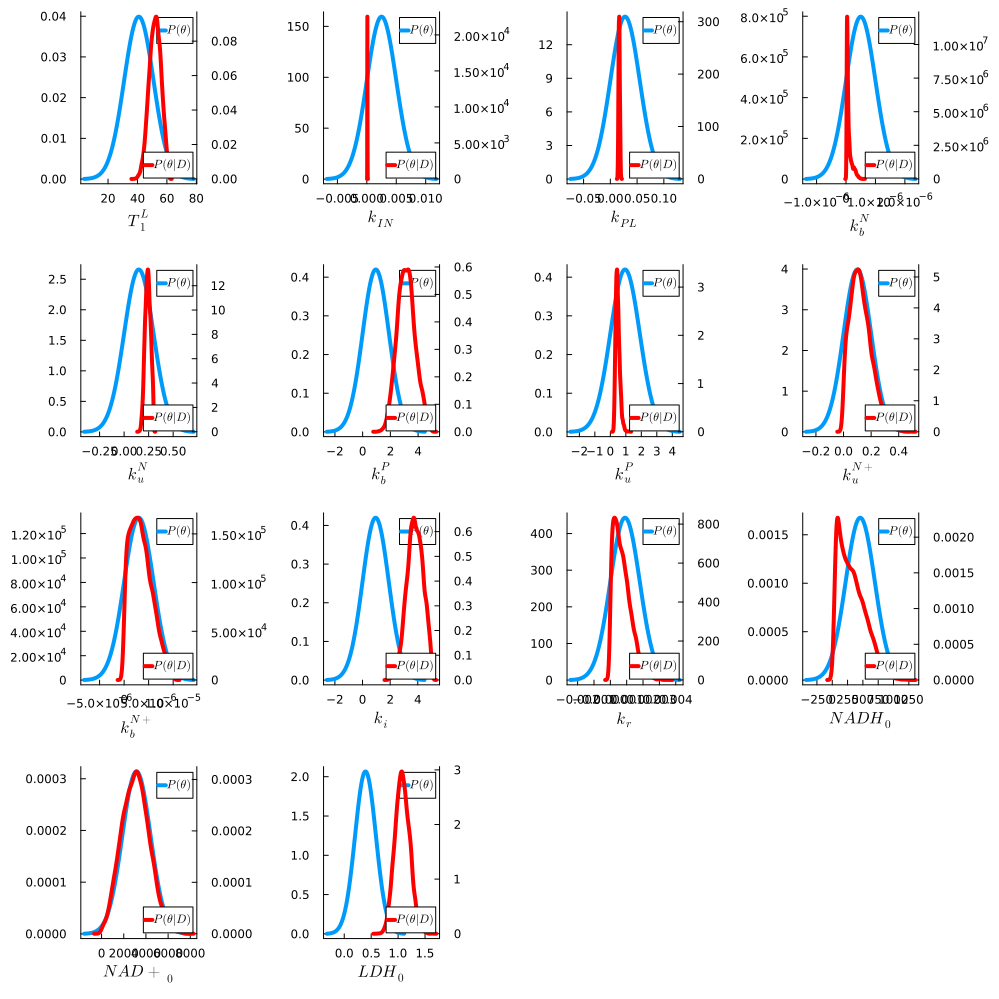

In [6]:
println(postNms[POSTNUM])

namess = [L"T_1^L",L"k_{IN}",L"k_{PL}",L"k_b^N",L"k_u^N",L"k_b^P",L"k_u^P",L"k_u^{N+}",L"k_b^{N+}",L"k_i",L"k_r",L"NADH_0",L"NAD+_0",L"LDH_0"];

postss = Array{Any}(undef, length(namess))

for i in 1:length(namess)

    ppt1=[]
    try
        ppt1 = plot(vcat(priorTheta[1], priorTheta[3:12], priotY0)[i].untruncated, label = L"P(\theta)", grid = false, linewidth=4, xlabel = namess[i],legend=:topright)
    catch
        ppt1 = plot(vcat(priorTheta[1], priorTheta[3:12], priotY0)[i], label = L"P(\theta)", grid = false, linewidth=4, xlabel = namess[i],legend=:topright)
    end
    plot!(twinx(), kde(postersCut[POSTNUM][:,i]), label=L"P(\theta | D)", linewidth=4, colour = "Red",legend=:bottomright)

    postss[i] = ppt1
end

tts1 = plot(postss..., size = (1000,1000))


# Compute -log covariances and save results

In [7]:
if !isdir(mainP*"PosteriorAnalysis")
    mkdir(mainP*"PosteriorAnalysis")
end

In [8]:
covsAll = zeros(length(postersCut))

for i in 1:length(postersCut)
    covsAll[i] = -log(det(cov(postersCut[i])))
end

JLD2.save(mainP*"PosteriorAnalysis\\CovarsAll.jld", "covsAll", covsAll)

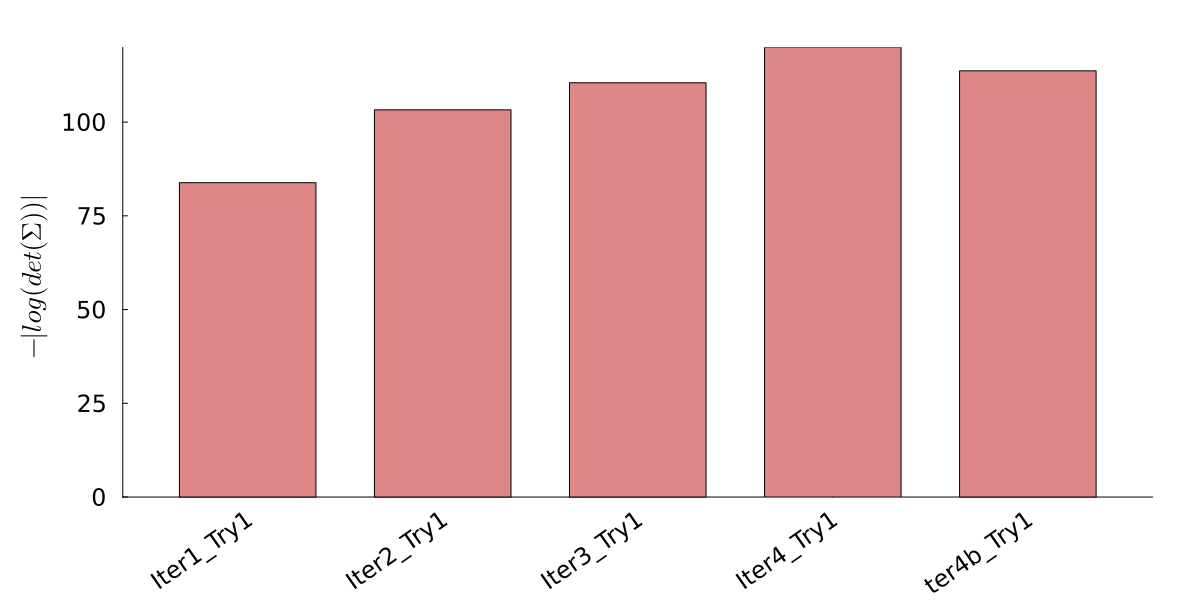

In [9]:
bar(covsAll, bar_width=0.7, xticks = (1:length(postNms), [postNms[i][end-9:end] for i in 1:length(postNms)]), xrotation = 35,
        ylabel = L"-|log(det(\Sigma))|", margin=10Plots.mm,xtickfont=font(16), ytickfont=font(16), guidefont=font(18), titlefont=font(18),
        size = (1200,600), grid = false, label = "", colour = "#de8787ff")

# Entropy Difference

In [10]:
include("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\EntropyEstimationPosterior.jl")
using ScikitLearn.GridSearch
using ScikitLearnBase
using GaussianMixtures

In [11]:
priSet = vcat(priorTheta[1], priorTheta[3:12], priotY0)
mes = zeros(length(priSet))
sts = zeros(length(priSet))

for i in 1:length(priSet)
    try
        mes[i] = vcat(priorTheta[1], priorTheta[3:12], priotY0)[i].untruncated.μ
        sts[i] = vcat(priorTheta[1], priorTheta[3:12], priotY0)[i].untruncated.σ
    catch
        mes[i] = vcat(priorTheta[1], priorTheta[3:12], priotY0)[i].μ
        sts[i] = vcat(priorTheta[1], priorTheta[3:12], priotY0)[i].σ
    end
end

HPrior = entropy(MvNormal(mes, Diagonal(ones(length(mes))).*sts));
HPrior

2.4147756004256102

In [12]:
gridsInit = Array{Any}(undef, length(postersCut))

5-element Vector{Any}:
 #undef
 #undef
 #undef
 #undef
 #undef

In [17]:
i = 1
gridsInit = Array{Any}(undef, length(postersCut))

for i in 1:length(postersCut)
    while !isassigned(gridsInit, i)
        try
                grid_searchM1FR2 = ScikitLearnBase.fit!(GridSearchCV(GMM(n_components=10, kind=:full), 
                        Dict(:n_components=>collect(1:10)), verbose=0), postersCut[i])

                grid_searchM1FbR2 = ScikitLearnBase.fit!(GridSearchCV(GMM(n_components=grid_searchM1FR2.best_estimator_.n*4, kind=:full), 
                        Dict(:n_components=>collect(grid_searchM1FR2.best_estimator_.n*4:grid_searchM1FR2.best_estimator_.n*4)), verbose=0), postersCut[i])

                zim = sum(grid_searchM1FbR2.best_estimator_.w .== 0)
                if zim != 0
                        grid_searchM1FbR2 = ScikitLearnBase.fit!(GridSearchCV(GMM(n_components=grid_searchM1FR2.best_estimator_.n*3, kind=:full), 
                        Dict(:n_components=>collect(grid_searchM1FR2.best_estimator_.n*3:grid_searchM1FR2.best_estimator_.n*3)), verbose=0), posterR2Cut)
                end
                gridsInit[i] = grid_searchM1FbR2
        catch
                nothing
        end

    end
end


In [25]:
# First dimension number of experiments, second dimension type of experiments.
comps = Array{Any,2}(undef,1, length(gridsInit));
weis = Array{Any,2}(undef, 1, length(gridsInit));
meaas = Array{Any,2}(undef,1, length(gridsInit));
covas = Array{Any,2}(undef,1, length(gridsInit));

for i in 1:length(gridsInit) #number of experiments
    if isassigned(postersCut,i)  
        # Get and store best results
        comps[1,i] = length(gridsInit[i].best_estimator_.w); # Number of components
        weis[1,i]  = gridsInit[i].best_estimator_.w; # Weights for each component
        meaas[1,i] = gridsInit[i].best_estimator_.μ; # Means for each component
        covas[1,i] = [inv(Matrix(gridsInit[i].best_estimator_.Σ[j]))*inv(Matrix(gridsInit[i].best_estimator_.Σ[j])') 
            for j in 1:length(gridsInit[i].best_estimator_.Σ)]; # Covariance Matrix for each component
    end
end


In [28]:
JLD2.save("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_Y0Measured\\Results\\PosteriorAnalysis\\GMMPostersIndiv.jld", "comps", comps, "weis", weis, "meaas", meaas, "covas", covas)

In [29]:
comps = JLD2.load("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_Y0Measured\\Results\\PosteriorAnalysis\\GMMPostersIndiv.jld")["comps"];
weis = JLD2.load("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_Y0Measured\\Results\\PosteriorAnalysis\\GMMPostersIndiv.jld")["weis"];
meaas = JLD2.load("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_Y0Measured\\Results\\PosteriorAnalysis\\GMMPostersIndiv.jld")["meaas"];
covas = JLD2.load("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_Y0Measured\\Results\\PosteriorAnalysis\\GMMPostersIndiv.jld")["covas"];

In [30]:
H_U_Post = Array{Any,2}(undef,1,length(gridsInit));
H_L_Post = Array{Any,2}(undef,1,length(gridsInit));
H_Post = Array{Any,2}(undef,1,length(gridsInit));

for j in 1#1:3# number of experiments
    [H_U_Post[j,i] = H_Upper(weis[j,i], covas[j,i]) for i in 1:length(gridsInit) if isassigned(postersCut,i) ];
    [H_L_Post[j,i] = H_Lower(weis[j,i], covas[j,i], meaas[j,i]) for i in 1:length(gridsInit) if isassigned(postersCut,i) ];
    [H_Post[j,i] = H_est(comps[j,i], weis[j,i], meaas[j,i], covas[j,i]) for i in 1:length(gridsInit) if isassigned(postersCut,i) ];
end

In [31]:
JLD2.save("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_Y0Measured\\Results\\PosteriorAnalysis\\EntroPostersIndiv.jld", "H_U_Post", H_U_Post, "H_L_Post", H_L_Post, "H_Post", H_Post, "HPrior", HPrior)

In [32]:
H_U_Post = JLD2.load("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_Y0Measured\\Results\\PosteriorAnalysis\\EntroPostersIndiv.jld")["H_U_Post"];
H_L_Post = JLD2.load("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_Y0Measured\\Results\\PosteriorAnalysis\\EntroPostersIndiv.jld")["H_L_Post"];
H_Post = JLD2.load("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_Y0Measured\\Results\\PosteriorAnalysis\\EntroPostersIndiv.jld")["H_Post"];

In [36]:

i = 1

display(string("ITERATION 1:"))
display(string("              |     H Lower Bound      |            H            |      H Upper Bound      |"))
display("--------------------------------------------------------------------------------------------")
for j in 1:5
if isassigned(postersCut,j) 
display(string("|     ",j,"     |         ",round(H_L_Post[i,j], digits = 2),"         |         ",round(H_Post[i,j], digits = 2),"          |          ",round(H_U_Post[i,j], digits = 2),"         |"))
end
end

"ITERATION 1:"

"              |     H Lower Bound      |            H            |      H Upper Bound      |"

"--------------------------------------------------------------------------------------------"

"|     1     |         -36.09         |         -34.0          |          -22.53         |"

"|     2     |         -47.08         |         -44.87          |          -33.59         |"

"|     3     |         -51.6         |         -49.41          |          -38.19         |"

"|     4     |         -56.44         |         -54.22          |          -43.04         |"

"|     5     |         -53.66         |         -51.55          |          -40.21         |"

In [37]:
H_Post

1×5 Matrix{Any}:
 -34.0014  -44.8661  -49.4121  -54.2173  -51.5466

In [39]:
H_gain = zeros(1,length(postersCut));
[H_gain[j,i] = HPrior-H_Post[j,i] for i in 1:length(postersCut) for j in 1:1 if isassigned(H_Post,j,i) ];


In [40]:
JLD2.save("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_Y0Measured\\Results\\PosteriorAnalysis\\EntropyGainIndiv.jld", "H_gain", H_gain)

In [41]:
H_gain = JLD2.load("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_Y0Measured\\Results\\PosteriorAnalysis\\EntropyGainIndiv.jld")["H_gain"]

1×5 Matrix{Float64}:
 36.4161  47.2808  51.8268  56.6321  53.9614

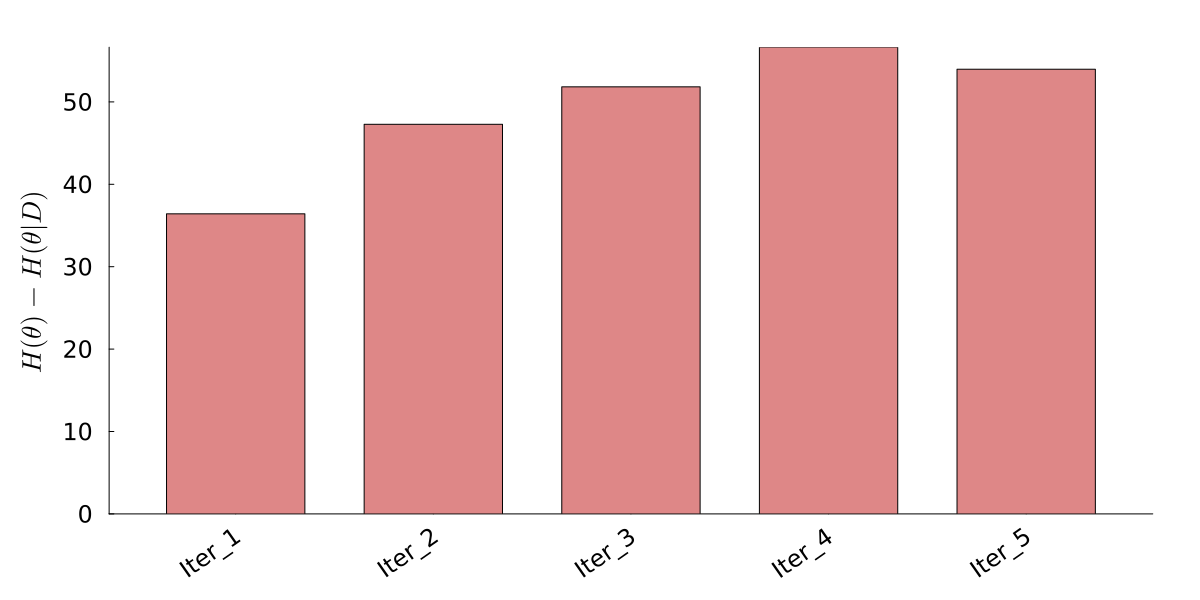

In [44]:
bar(H_gain[1,:], bar_width=0.7, xticks = (1:length(postersCut), ["Iter_"*string(i) for i in 1:length(postersCut)]), xrotation = 35,
        ylabel = L"H(\theta) - H(\theta | D)", margin=10Plots.mm,xtickfont=font(16), ytickfont=font(16), guidefont=font(18), titlefont=font(18),
        size = (1200,600), grid = false, label = "", colour = "#de8787ff")